# **1. Problem Formulation:**

- We want to understand the factors that affect the Air Quality Index

In [1]:
# Packages / libraries
import os #provides functions for interacting with the operating system
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
# remove warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# **2. Loading the Raw Data**

In [2]:
# Loading the data
raw_data = pd.read_csv(r"/kaggle/input/combined-data/data_2015_2024.csv")

# print the shape
print(raw_data.shape)

#runs the first 5 rows
raw_data.head(5)

(1462740, 28)


,Unnamed: 0,Date,Country,City,aqi,co,mepaqi,neph,no2,o3,...,pm1,pressure,temperature,wd,wind-speed,precipitation,wind-gust,dew,wind gust,wind speed
0,0,2014-12-29,AT,Graz,NaN,0.1,NaN,NaN,52.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2014-12-29,AT,Innsbruck,NaN,0.1,NaN,NaN,46.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2014-12-29,AT,Linz,NaN,0.1,NaN,NaN,34.3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2014-12-29,AT,Salzburg,NaN,0.1,NaN,NaN,43.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2014-12-29,AT,Vienna,NaN,0.1,NaN,NaN,22.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Find the minimum and maximum dates
min_date = raw_data['Date'].min()
max_date = raw_data['Date'].max()

print('Minimum date:', min_date)
print('Maximum date:', max_date)

Minimum date: 2014-12-29
Maximum date: 2024-12-31


# **3. Data Preprocessing**

# **3.1 - Investigating dataset**

In [4]:
raw_data.columns

Index(['Unnamed: 0', 'Date', 'Country', 'City', 'aqi', 'co', 'mepaqi', 'neph',
       'no2', 'o3', 'pm10', 'pm25', 'psi', 'so2', 'uvi', 'pol', 'd',
       'humidity', 'pm1', 'pressure', 'temperature', 'wd', 'wind-speed',
       'precipitation', 'wind-gust', 'dew', 'wind gust', 'wind speed'],
      dtype='object')

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462740 entries, 0 to 1462739
Data columns (total 28 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Unnamed: 0     1462740 non-null  int64  
 1   Date           1462740 non-null  object 
 2   Country        1462740 non-null  object 
 3   City           1462740 non-null  object 
 4   aqi            35345 non-null    float64
 5   co             922394 non-null   float64
 6   mepaqi         2589 non-null     float64
 7   neph           4654 non-null     float64
 8   no2            1208924 non-null  float64
 9   o3             1142329 non-null  float64
 10  pm10           1194521 non-null  float64
 11  pm25           1233890 non-null  float64
 12  psi            363 non-null      float64
 13  so2            1007299 non-null  float64
 14  uvi            29317 non-null    float64
 15  pol            4958 non-null     float64
 16  d              2031 non-null     float64
 17  humidity

In [6]:
raw_data.describe()

,Unnamed: 0,aqi,co,mepaqi,neph,no2,o3,pm10,pm25,psi,...,pm1,pressure,temperature,wd,wind-speed,precipitation,wind-gust,dew,wind gust,wind speed
count,1.462740e+06,35345.000000,922394.000000,2589.000000,4654.000000,1.208924e+06,1.142329e+06,1.194521e+06,1.233890e+06,363.000000,...,5374.000000,1.105830e+06,1.110494e+06,82471.000000,1.046929e+06,125192.000000,613948.000000,847045.000000,31765.000000,49751.000000
mean,7.313695e+05,73.563206,12.384552,89.698416,36.217748,3.006112e+01,4.031038e+01,7.225309e+01,1.062283e+02,60.900826,...,118.154038,1.008055e+03,2.248106e+01,291.845146,7.134132e+00,78.833211,13.997933,12.947534,15.066136,7.982469
std,4.222568e+05,69.428629,24.254905,54.153124,95.143833,2.290536e+01,3.161829e+01,1.097705e+02,8.693943e+01,9.510162,...,58.820557,1.206222e+02,3.572070e+01,99.044102,1.476321e+01,122.774242,10.639402,15.241574,10.606689,14.441722
min,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,31.000000,...,11.000000,-2.153000e+03,-8.280000e+01,0.000000,0.000000e+00,-1.000000,0.100000,-42.000000,0.100000,0.100000
25%,3.656848e+05,46.000000,2.900000,61.600000,13.000000,1.600000e+01,2.560000e+01,2.800000e+01,5.800000e+01,54.000000,...,72.000000,1.011900e+03,1.480000e+01,292.500000,4.100000e+00,3.200000,9.100000,7.000000,9.200000,4.100000
50%,7.313695e+05,58.000000,7.000000,81.400000,20.000000,2.570000e+01,3.500000e+01,4.900000e+01,8.200000e+01,59.000000,...,104.000000,1.017400e+03,2.300000e+01,337.500000,5.800000e+00,99.000000,12.600000,13.000000,13.300000,6.100000
75%,1.097054e+06,71.000000,13.700000,106.500000,32.000000,3.800000e+01,4.590000e+01,7.400000e+01,1.420000e+02,67.000000,...,160.000000,1.023000e+03,3.000000e+01,350.000000,8.200000e+00,99.300000,16.900000,19.800000,18.600000,9.000000
max,1.462739e+06,500.000000,500.000000,483.700000,2552.000000,7.140000e+02,1.260000e+03,3.231500e+03,3.063000e+03,106.000000,...,500.000000,3.276700e+03,3.276000e+03,1681.000000,3.078800e+03,3270.100000,861.000000,2924.000000,327.000000,783.800000


In [7]:
# Investigate all the elements whithin each Feature

for column in raw_data:
    # Handle numerical and string columns differently
    if raw_data[column].dtype == 'object':  # Check if column is of object type
        unique_vals = raw_data[column].unique()  # pandas unique for strings
    else:
        unique_vals = np.unique(raw_data[column])  # numpy unique for numerical types

    nr_values = len(unique_vals)
    if nr_values < 14:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values,unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature Unnamed: 0 :1462740
The number of values for feature Date :2858
The number of values for feature Country :95
The number of values for feature City :616
The number of values for feature aqi :475
The number of values for feature co :2903
The number of values for feature mepaqi :1068
The number of values for feature neph :232
The number of values for feature no2 :2345
The number of values for feature o3 :3024
The number of values for feature pm10 :1806
The number of values for feature pm25 :1466
The number of values for feature psi :45
The number of values for feature so2 :2784
The number of values for feature uvi :119
The number of values for feature pol :19
The number of values for feature d :59
The number of values for feature humidity :1844
The number of values for feature pm1 :390
The number of values for feature pressure :7134
The number of values for feature temperature :1891
The number of values for feature wd :2272
The number of values for feature

# **3.2 - Removing Duplicates and Null values(Instance/Column)**

In [8]:
raw_data.isna().sum()

Unnamed: 0             0
Date                   0
Country                0
City                   0
aqi              1427395
co                540346
mepaqi           1460151
neph             1458086
no2               253816
o3                320411
pm10              268219
pm25              228850
psi              1462377
so2               455441
uvi              1433423
pol              1457782
d                1460709
humidity          353140
pm1              1457366
pressure          356910
temperature       352246
wd               1380269
wind-speed        415811
precipitation    1337548
wind-gust         848792
dew               615695
wind gust        1430975
wind speed       1412989
dtype: int64

In [9]:
raw_data.columns

Index(['Unnamed: 0', 'Date', 'Country', 'City', 'aqi', 'co', 'mepaqi', 'neph',
       'no2', 'o3', 'pm10', 'pm25', 'psi', 'so2', 'uvi', 'pol', 'd',
       'humidity', 'pm1', 'pressure', 'temperature', 'wd', 'wind-speed',
       'precipitation', 'wind-gust', 'dew', 'wind gust', 'wind speed'],
      dtype='object')

In [10]:
# removing columns where missing values is more than 600,000
new_data = raw_data.drop(['Unnamed: 0','aqi','mepaqi','neph', 'psi','uvi', 'pol', 'd','pm1','wd',
                         'precipitation', 'wind-gust', 'dew', 'wind gust', 'wind speed'], axis=1)

In [11]:
new_data.columns

Index(['Date', 'Country', 'City', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
       'humidity', 'pressure', 'temperature', 'wind-speed'],
      dtype='object')

In [12]:
new_data.isna().sum()

Date                0
Country             0
City                0
co             540346
no2            253816
o3             320411
pm10           268219
pm25           228850
so2            455441
humidity       353140
pressure       356910
temperature    352246
wind-speed     415811
dtype: int64

In [13]:
# removing rows where 'pm10', 'pm25' all are missing
# most cases pm10, pm25 have direct influence in AQI count
new_data = new_data.dropna(subset=['pm10', 'pm25'], how='all', inplace=False)

In [14]:
new_data.shape

(1394447, 13)

In [15]:
new_data.isna().sum()

Date                0
Country             0
City                0
co             477196
no2            201211
o3             264785
pm10           199926
pm25           160557
so2            403923
humidity       337707
pressure       341666
temperature    336985
wind-speed     395848
dtype: int64

In [16]:
# check for duplicates rows
# Selecting duplicate rows except first
# occurrence based on all columns
duplicate = new_data[new_data.duplicated()]

print("Duplicate Rows :")
duplicate

Duplicate Rows :


,Date,Country,City,co,no2,o3,pm10,pm25,so2,humidity,pressure,temperature,wind-speed
508559,2019-09-30,AE,Abu Dhabi,0.1,36.2,59.1,105.0,163.0,6.6,79.0,1008.0,41.0,7.7
508560,2019-09-30,AE,Dubai,NaN,NaN,32.1,NaN,169.0,NaN,79.0,1008.0,38.0,6.6
508561,2019-09-30,AR,Buenos Aires,10.3,21.1,7.4,49.0,99.0,19.8,82.0,1007.4,26.6,12.2
508562,2019-09-30,AT,Graz,0.1,24.7,NaN,55.0,NaN,16.3,91.8,1014.8,24.5,4.6
508563,2019-09-30,AT,Innsbruck,0.1,27.9,NaN,32.0,NaN,1.1,95.2,1015.0,23.5,7.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339097,2023-10-01,RO,Timişoara,NaN,15.8,25.2,18.0,NaN,4.4,89.6,1023.0,23.8,5.1
1339104,2023-10-01,SK,Bratislava,4.8,34.3,NaN,28.0,70.0,2.6,93.1,1026.0,22.0,5.0
1339105,2023-10-01,SK,Košice,10.2,17.0,NaN,46.0,72.0,7.6,88.0,1022.5,17.9,7.0
1339106,2023-10-01,SV,San Salvador,NaN,NaN,NaN,NaN,50.0,NaN,92.7,1016.9,29.1,1.5


In [17]:
# Remove duplicate rows
new_data_cleaned = new_data.drop_duplicates()

# Verify the removal of duplicates
print(f"Shape of original data: {new_data.shape}")
print(f"Shape after removing duplicates: {new_data_cleaned.shape}")

Shape of original data: (1394447, 13)
Shape after removing duplicates: (1342220, 13)


In [18]:
new_data_cleaned.head()

,Date,Country,City,co,no2,o3,pm10,pm25,so2,humidity,pressure,temperature,wind-speed
0,2014-12-29,AT,Graz,0.1,52.5,NaN,116.0,NaN,4.6,NaN,NaN,NaN,NaN
1,2014-12-29,AT,Innsbruck,0.1,46.7,NaN,39.0,NaN,2.1,NaN,NaN,NaN,NaN
2,2014-12-29,AT,Linz,0.1,34.3,NaN,50.0,102.0,21.8,NaN,NaN,NaN,NaN
3,2014-12-29,AT,Salzburg,0.1,43.0,NaN,46.0,NaN,3.6,NaN,NaN,NaN,NaN
4,2014-12-29,AT,Vienna,0.1,22.9,NaN,37.0,80.0,4.1,NaN,NaN,NaN,NaN


🇦🇫 Afghanistan - 🇦🇱 Albania - 🇩🇿 Algeria - 🇦🇷 Argentina - 🇦🇲 Armenia - 🇦🇼 Aruba - 🇦🇺 Australia - 🇦🇹 Austria - 🇦🇿 Azerbaijan - 🇧🇭 Bahrain - 🇧🇩 Bangladesh - 🇧🇾 Belarus - 🇧🇪 Belgium - 🇧🇯 Benin - 🇧🇹 Bhutan - 🇧🇴 Bolivia - 🇧🇦 Bosnia and Herzegovina - 🇧🇷 Brazil - 🇧🇳 Brunei - 🇧🇬 Bulgaria - 🇧🇫 Burkina Faso - 🇧🇮 Burundi - 🇨🇻 Cabo Verde - 🇰🇭 Cambodia - 🇨🇲 Cameroon - 🇨🇦 Canada - 🇨🇱 Chile - 🇨🇳 China - 🇨🇴 Colombia - 🇨🇷 Costa Rica - 🇭🇷 Croatia - 🇨🇺 Cuba - 🇨🇾 Cyprus - 🇨🇿 Czechia - 🇨🇩 DR Congo - 🇩🇰 Denmark - 🇩🇴 Dominican Republic - 🇪🇨 Ecuador - 🇪🇬 Egypt - 🇸🇻 El Salvador - 🇪🇷 Eritrea - 🇪🇪 Estonia - 🇪🇹 Ethiopia - 🇫🇰 Falkland Islands - 🇫🇮 Finland - 🇫🇷 France - 🇬🇪 Georgia - 🇩🇪 Germany - 🇬🇭 Ghana - 🇬🇷 Greece - 🇬🇩 Grenada - 🇬🇹 Guatemala - 🇭🇳 Honduras - 🇭🇰 Hong Kong - 🇭🇺 Hungary - 🇮🇸 Iceland - 🇮🇳 India - 🇮🇩 Indonesia - 🇮🇷 Iran - 🇮🇶 Iraq - 🇮🇪 Ireland - 🇮🇱 Israel - 🇮🇹 Italy - 🇨🇮 Ivory Coast - 🇯🇵 Japan - 🇯🇴 Jordan - 🇰🇿 Kazakhstan - 🇰🇪 Kenya - 🇽🇰 Kosovo - 🇰🇼 Kuwait - 🇰🇬 Kyrgyzstan - 🇱🇦 Laos - 🇱🇻 Latvia - 🇱🇧 Lebanon - 🇱🇾 Libya - 🇱🇹 Lithuania - 🇱🇺 Luxembourg - 🇲🇴 Macao - 🇲🇬 Madagascar - 🇲🇾 Malaysia - 🇲🇻 Maldives - 🇲🇱 Mali - 🇲🇹 Malta - 🇲🇺 Mauritius - 🇲🇽 Mexico - 🇲🇩 Moldova - 🇲🇨 Monaco - 🇲🇳 Mongolia - 🇲🇪 Montenegro - 🇲🇦 Morocco - 🇲🇲 Myanmar - 🇳🇵 Nepal - 🇳🇿 New Zealand - 🇳🇮 Nicaragua - 🇳🇬 Nigeria - 🇲🇰 North Macedonia - 🇳🇴 Norway - 🇴🇲 Oman - 🇵🇰 Pakistan - 🇵🇦 Panama - 🇵🇬 Papua New Guinea - 🇵🇾 Paraguay - 🇵🇪 Peru - 🇵🇭 Philippines - 🇵🇱 Poland - 🇵🇹 Portugal - 🇵🇷 Puerto Rico - 🇶🇦 Qatar - 🇷🇴 Romania - 🇷🇺 Russia - 🇷🇼 Rwanda - 🇷🇪 Réunion - 🇸🇲 San Marino - 🇸🇦 Saudi Arabia - 🇸🇳 Senegal - 🇷🇸 Serbia - 🇸🇨 Seychelles - 🇸🇬 Singapore - 🇸🇰 Slovakia - 🇸🇮 Slovenia - 🇿🇦 South Africa - 🇰🇷 South Korea - 🇪🇸 Spain - 🇱🇰 Sri Lanka - 🇸🇪 Sweden - 🇨🇭 Switzerland - 🇸🇾 Syria - 🇹🇼 Taiwan - 🇹🇯 Tajikistan - 🇹🇭 Thailand - 🇳🇱 The Netherlands - 🇹🇬 Togo - 🇹🇹 Trinidad and Tobago - 🇹🇳 Tunisia - 🇹🇷 Türkiye - 🇻🇮 U.S. Virgin Islands - 🇺🇬 Uganda - 🇺🇦 Ukraine - 🇦🇪 United Arab Emirates - 🇬🇧 United Kingdom - 🇺🇸 United States - 🇺🇾 Uruguay - 🇺🇿 Uzbekistan - 🇻🇺 Vanuatu - 🇻🇪 Venezuela - 🇻🇳 Vietnam - 🇿🇲 Zambia - 🇿🇼 Zimbabwe -

In [19]:
new_data_cleaned['Country'].unique()

array(['AT', 'AU', 'BE', 'BO', 'BR', 'CA', 'CH', 'CL', 'CN', 'CO', 'CY',
       'CZ', 'DE', 'ES', 'FI', 'FR', 'GB', 'HK', 'HR', 'HU', 'IL', 'IN',
       'IT', 'JP', 'KR', 'LT', 'MN', 'MO', 'MX', 'NL', 'NO', 'PE', 'PL',
       'PT', 'RE', 'RU', 'SG', 'SK', 'SV', 'TH', 'TR', 'TW', 'US', 'VN',
       'ZA', 'DK', 'EC', 'RO', 'IR', 'SE', 'AE', 'MK', 'BG', 'RS', 'AR',
       'GT', 'ID', 'IS', 'NZ', 'BD', 'XK', 'BA', 'BH', 'ET', 'NP', 'KW',
       'EE', 'UG', 'LK', 'PH', 'IE', 'KZ', 'CW', 'PR', 'UZ', 'KG', 'JO',
       'UA', 'IQ', 'SA', 'LA', 'DZ', 'PK', 'MM', 'TJ', 'TM', 'GR', 'AF',
       'GE', 'CR', 'ML', 'CI', 'GN', 'GH'], dtype=object)

In [20]:
# Dictionary mapping abbreviations to full country names
country_mapping = {
    'AT': 'Austria',
    'AU': 'Australia',
    'BE': 'Belgium',
    'BO': 'Bolivia',
    'BR': 'Brazil',
    'CA': 'Canada',
    'CH': 'Switzerland',
    'CL': 'Chile',
    'CN': 'China',
    'CO': 'Colombia',
    'CY': 'Cyprus',
    'CZ': 'Czechia',
    'DE': 'Germany',
    'DK': 'Denmark',
    'ES': 'Spain',
    'FI': 'Finland',
    'FR': 'France',
    'GB': 'United Kingdom',
    'HK': 'Hong Kong',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IL': 'Israel',
    'IN': 'India',
    'IT': 'Italy',
    'JP': 'Japan',
    'KR': 'South Korea',
    'LT': 'Lithuania',
    'MN': 'Mongolia',
    'MO': 'Macao',
    'MX': 'Mexico',
    'MY': 'Malaysia',
    'NL': 'The Netherlands',
    'NO': 'Norway',
    'PE': 'Peru',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RE': 'Réunion',
    'RU': 'Russia',
    'SG': 'Singapore',
    'SK': 'Slovakia',
    'SV': 'El Salvador',
    'TH': 'Thailand',
    'TR': 'Türkiye',
    'TW': 'Taiwan',
    'US': 'United States',
    'VN': 'Vietnam',
    'ZA': 'South Africa',
    'EC': 'Ecuador',
    'RO': 'Romania',
    'IR': 'Iran',
    'SE': 'Sweden',
    'AE': 'United Arab Emirates',
    'MK': 'North Macedonia',
    'BG': 'Bulgaria',
    'RS': 'Serbia',
    'AR': 'Argentina',
    'PR': 'Puerto Rico',
    'GT': 'Guatemala',
    'ID': 'Indonesia',
    'IS': 'Iceland',
    'NZ': 'New Zealand',
    'BD': 'Bangladesh',
    'XK': 'Kosovo',
    'BA': 'Bosnia and Herzegovina',
    'BH': 'Bahrain',
    'ET': 'Ethiopia',
    'NP': 'Nepal',
    'KW': 'Kuwait',
    'EE': 'Estonia',
    'UG': 'Uganda',
    'LK': 'Sri Lanka',
    'PH': 'Philippines',
    'IE': 'Ireland',
    'KZ': 'Kazakhstan',
    'CW': 'Curaçao',
    'UZ': 'Uzbekistan',
    'KG': 'Kyrgyzstan',
    'UA': 'Ukraine',
    'JO': 'Jordan',
    'IQ': 'Iraq',
    'SA': 'Saudi Arabia',
    'LA': 'Laos',
    'DZ': 'Algeria',
    'PK': 'Pakistan',
    'MM': 'Myanmar',
    'TJ': 'Tajikistan',
    'TM': 'Turkmenistan',
    'GR': 'Greece',
    'AF': 'Afghanistan',
    'GE': 'Georgia',
    'CR': 'Costa Rica',
    'ML': 'Mali',
    'CI': 'Ivory Coast',
    'GN': 'Guinea',
    'GH': 'Ghana'
}

# Replace abbreviations with full country names
new_data_cleaned['Country'] = new_data_cleaned['Country'].replace(country_mapping)

new_data_cleaned.head()

<ipython-input-20-c44949f43a29>:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_cleaned['Country'] = new_data_cleaned['Country'].replace(country_mapping)


,Date,Country,City,co,no2,o3,pm10,pm25,so2,humidity,pressure,temperature,wind-speed
0,2014-12-29,Austria,Graz,0.1,52.5,NaN,116.0,NaN,4.6,NaN,NaN,NaN,NaN
1,2014-12-29,Austria,Innsbruck,0.1,46.7,NaN,39.0,NaN,2.1,NaN,NaN,NaN,NaN
2,2014-12-29,Austria,Linz,0.1,34.3,NaN,50.0,102.0,21.8,NaN,NaN,NaN,NaN
3,2014-12-29,Austria,Salzburg,0.1,43.0,NaN,46.0,NaN,3.6,NaN,NaN,NaN,NaN
4,2014-12-29,Austria,Vienna,0.1,22.9,NaN,37.0,80.0,4.1,NaN,NaN,NaN,NaN


In [21]:
new_data_cleaned['Country'].unique()

array(['Austria', 'Australia', 'Belgium', 'Bolivia', 'Brazil', 'Canada',
       'Switzerland', 'Chile', 'China', 'Colombia', 'Cyprus', 'Czechia',
       'Germany', 'Spain', 'Finland', 'France', 'United Kingdom',
       'Hong Kong', 'Croatia', 'Hungary', 'Israel', 'India', 'Italy',
       'Japan', 'South Korea', 'Lithuania', 'Mongolia', 'Macao', 'Mexico',
       'The Netherlands', 'Norway', 'Peru', 'Poland', 'Portugal',
       'Réunion', 'Russia', 'Singapore', 'Slovakia', 'El Salvador',
       'Thailand', 'Türkiye', 'Taiwan', 'United States', 'Vietnam',
       'South Africa', 'Denmark', 'Ecuador', 'Romania', 'Iran', 'Sweden',
       'United Arab Emirates', 'North Macedonia', 'Bulgaria', 'Serbia',
       'Argentina', 'Guatemala', 'Indonesia', 'Iceland', 'New Zealand',
       'Bangladesh', 'Kosovo', 'Bosnia and Herzegovina', 'Bahrain',
       'Ethiopia', 'Nepal', 'Kuwait', 'Estonia', 'Uganda', 'Sri Lanka',
       'Philippines', 'Ireland', 'Kazakhstan', 'Curaçao', 'Puerto Rico',
       'Uz

# **3.3 - EDA**

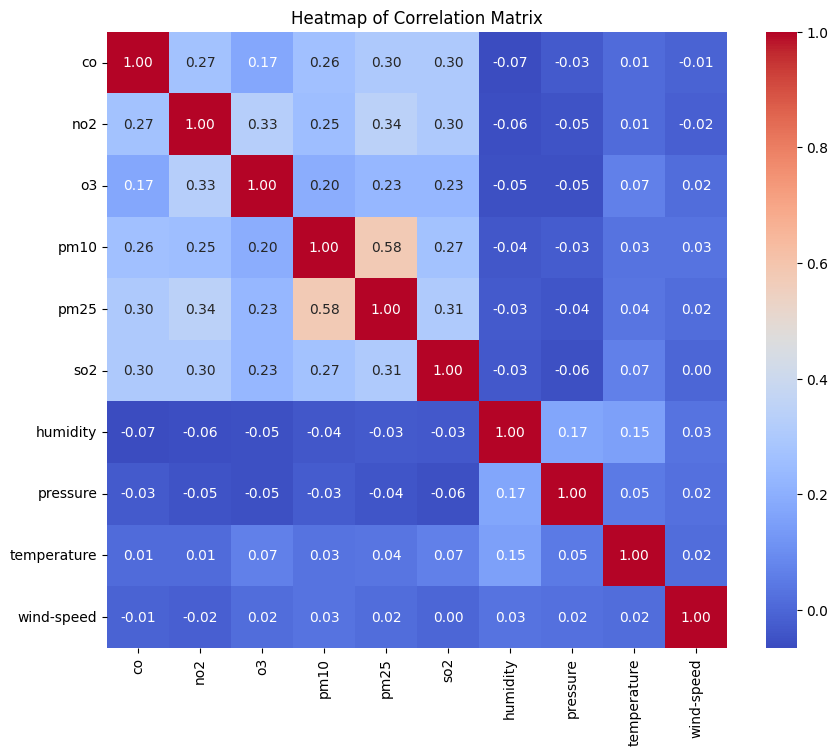

In [22]:
# Calculate the correlation matrix for numeric columns
corr = new_data_cleaned.corr(numeric_only=True)

# Create a heatmap using the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap of Correlation Matrix")
#file_name = "correlation_matrix_excluding_O3_Subindex.png"
#path = "/kaggle/working/data-after-combine"
#plt.savefig(path,file_name)
plt.show()

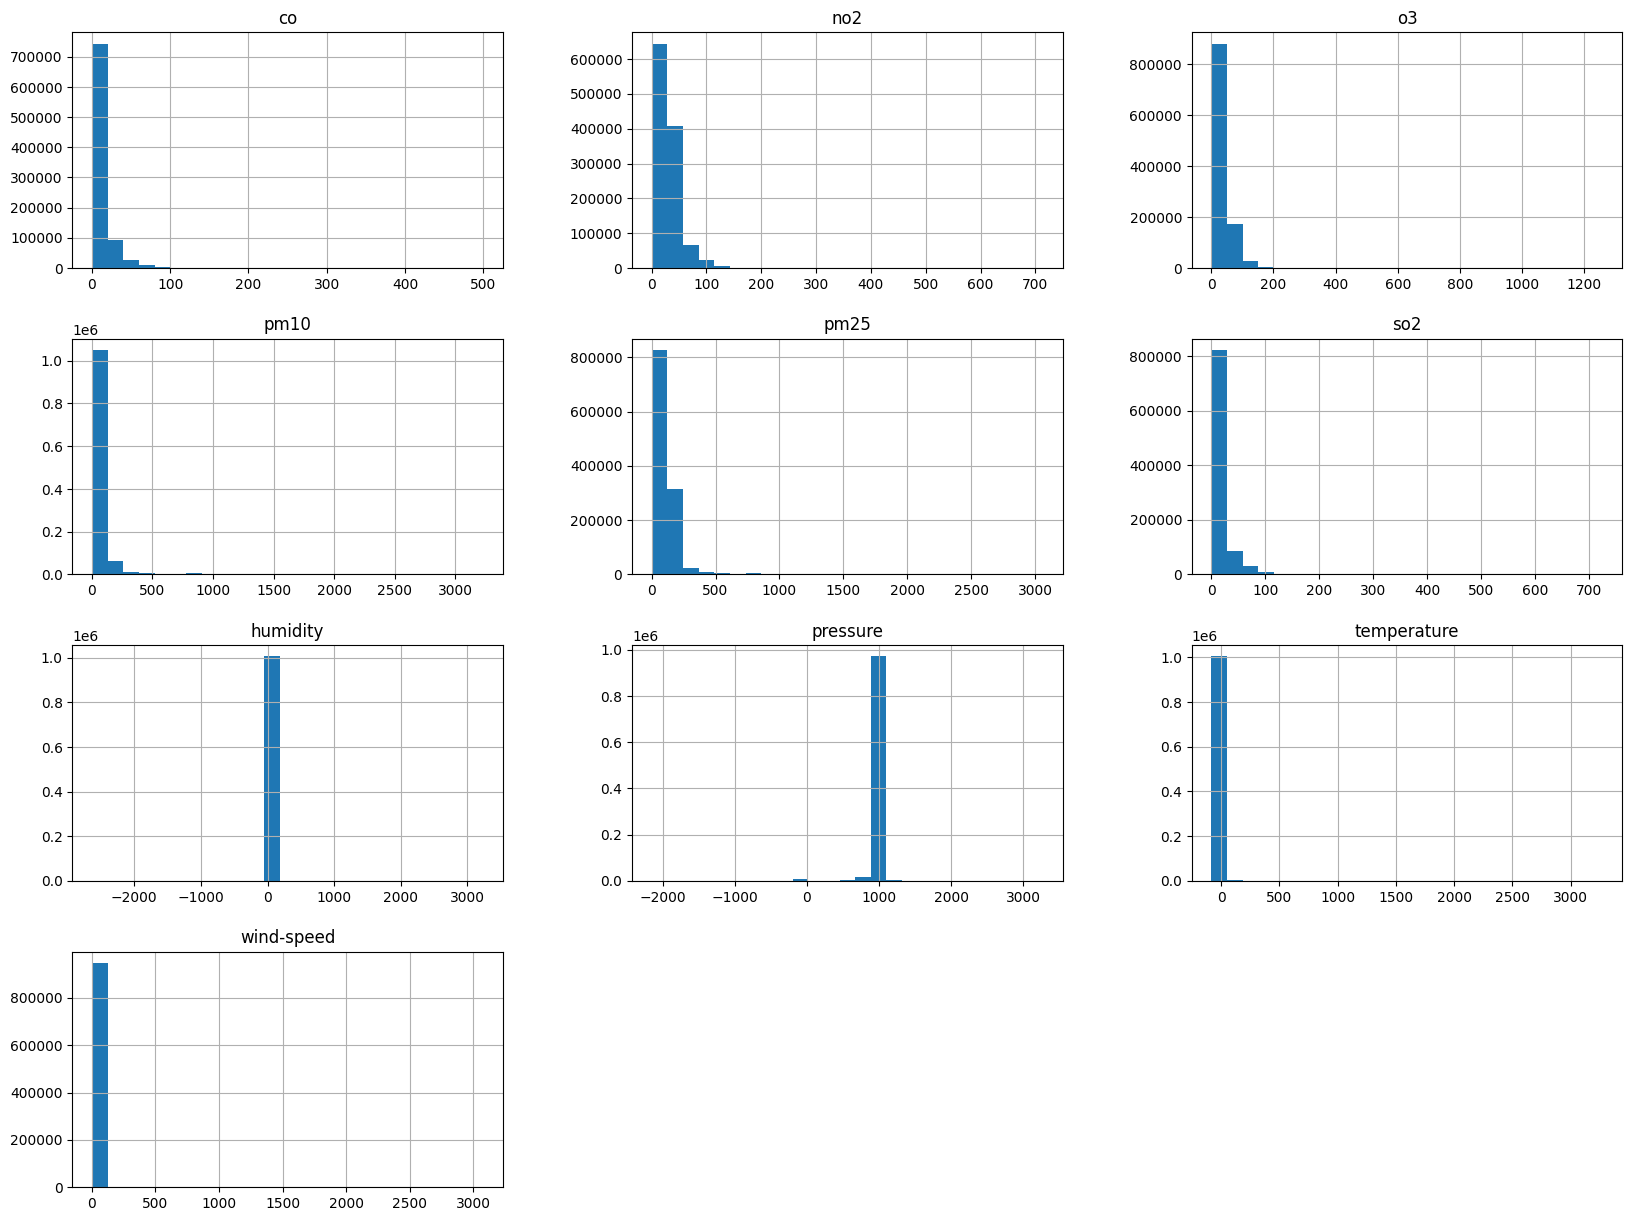

In [23]:
# plot hist plot
new_data_cleaned.hist(bins=25, figsize=(20,15))
#file_name = "hist_plot.png"
#path = "/kaggle/working/data-after-combine"
#plt.savefig(path,file_name)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


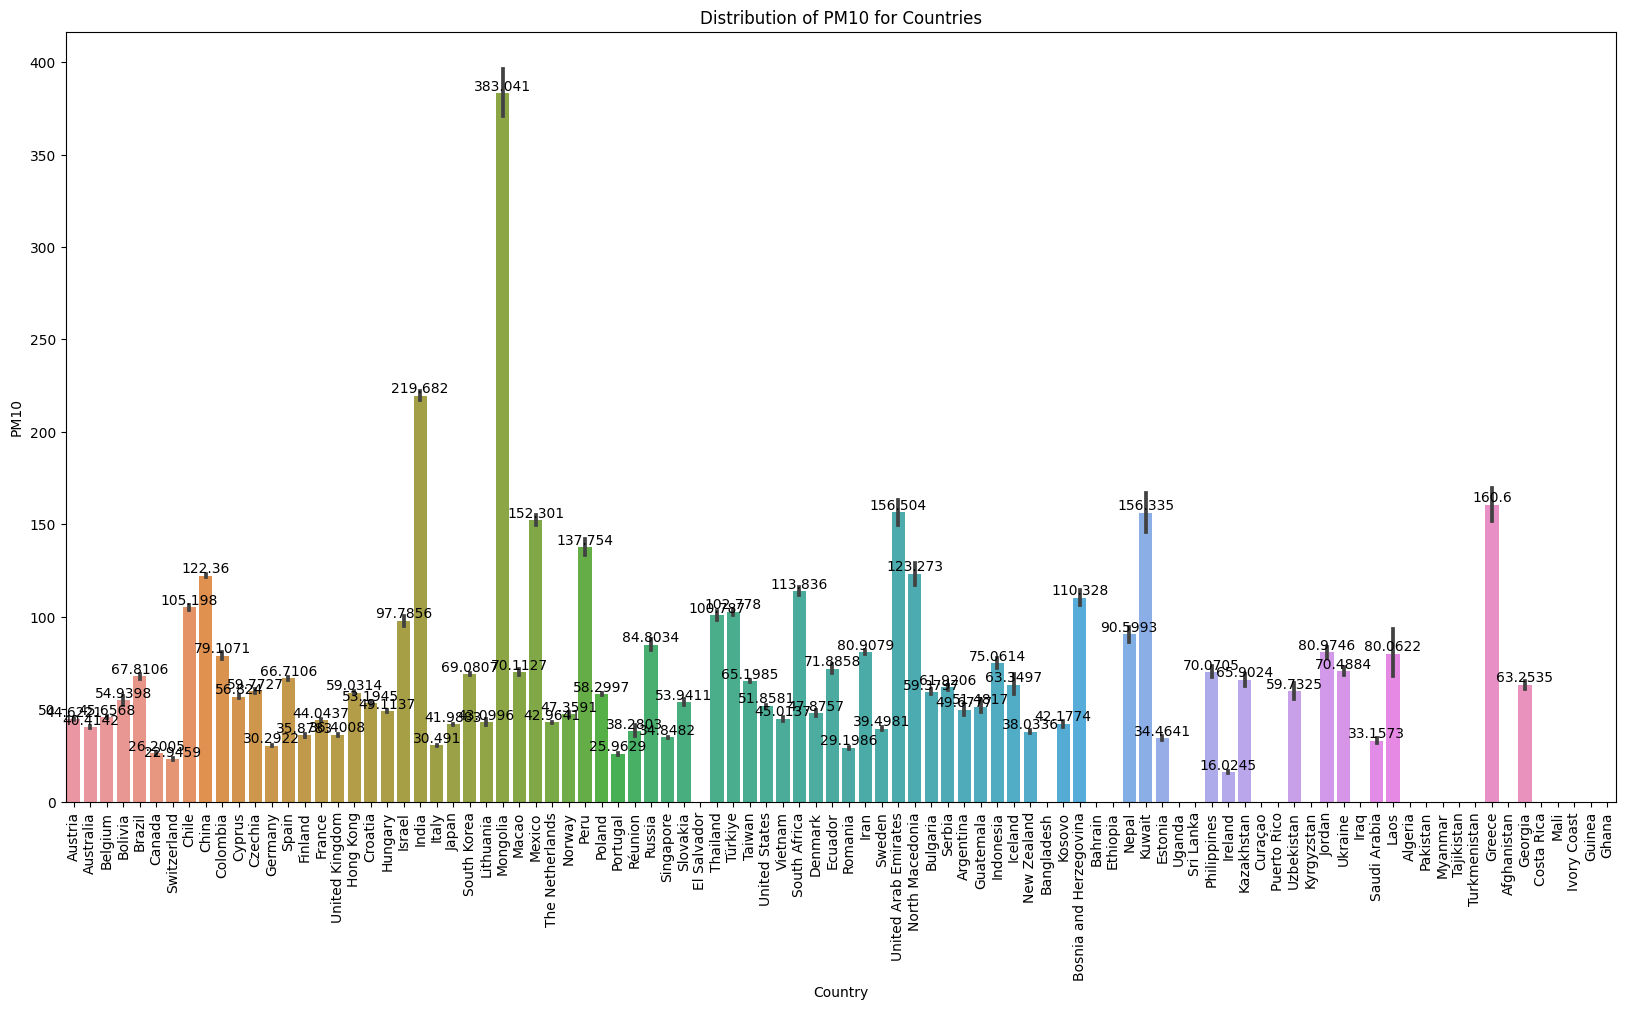

,Country,pm10
0,Afghanistan,NaN
1,Algeria,NaN
2,Argentina,49.677663
3,Australia,40.414151
4,Austria,44.622072
...,...,...
89,United Arab Emirates,156.504482
90,United Kingdom,36.400757
91,United States,51.858124
92,Uzbekistan,59.732484


In [24]:
# Plot the distribution of PM10 for the Countries
ax = sns.barplot(x="Country", y="pm10", data=new_data_cleaned)
ax.figure.set_size_inches(20, 10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.bar_label(ax.containers[0]) # Add levels to bars
ax.set_title("Distribution of PM10 for Countries")
ax.set_xlabel("Country")
ax.set_ylabel("PM10")
plt.show()

new_data_cleaned[['Country', 'pm10']].groupby('Country', as_index = False).agg({'pm10':'mean'})

In [25]:
city_pm25 = new_data_cleaned[['City', 'pm25']].groupby('City', as_index=False).agg({'pm25': 'mean'}) #mean PM2.5 for each city

top_10_cities = city_pm25.sort_values(by='pm25', ascending=False).head(10) # Sort by PM2.5 in descending order and top 10

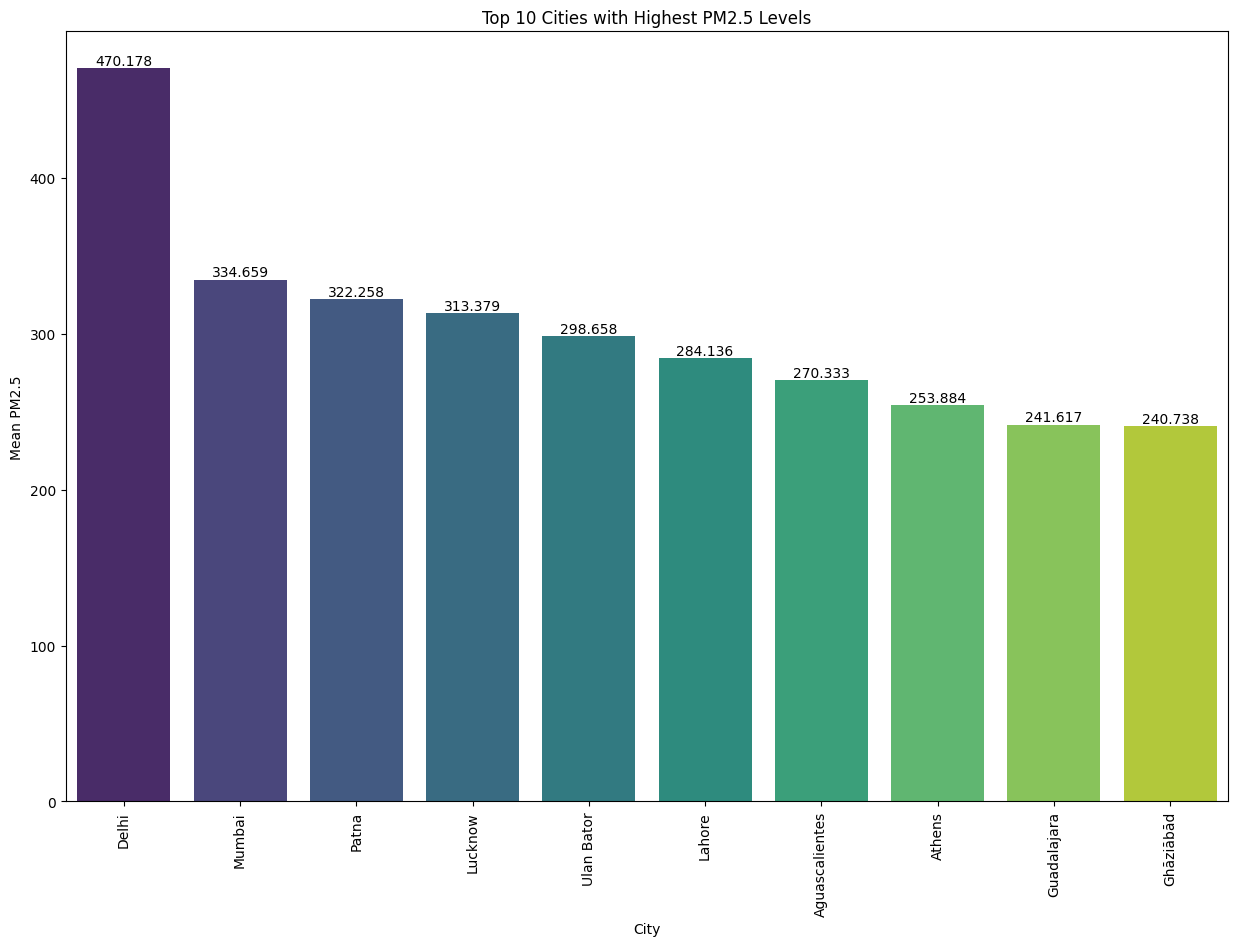

In [26]:
# Plot the distribution of PM2.5 for the top 10 cities
ax = sns.barplot(x="City", y="pm25", data=top_10_cities, palette="viridis")
ax.figure.set_size_inches(15, 10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.bar_label(ax.containers[0])  # Add labels to bars
plt.title("Top 10 Cities with Highest PM2.5 Levels")
plt.xlabel("City")
plt.ylabel("Mean PM2.5")
plt.show()

In [27]:
new_data_cleaned.columns

Index(['Date', 'Country', 'City', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
       'humidity', 'pressure', 'temperature', 'wind-speed'],
      dtype='object')

In [28]:
# top 5 countries by mean CO
top_countries = (
    new_data_cleaned.groupby('Country')['co']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter the data for only these countries
filtered_data = new_data_cleaned[new_data_cleaned['Country'].isin(top_countries)]

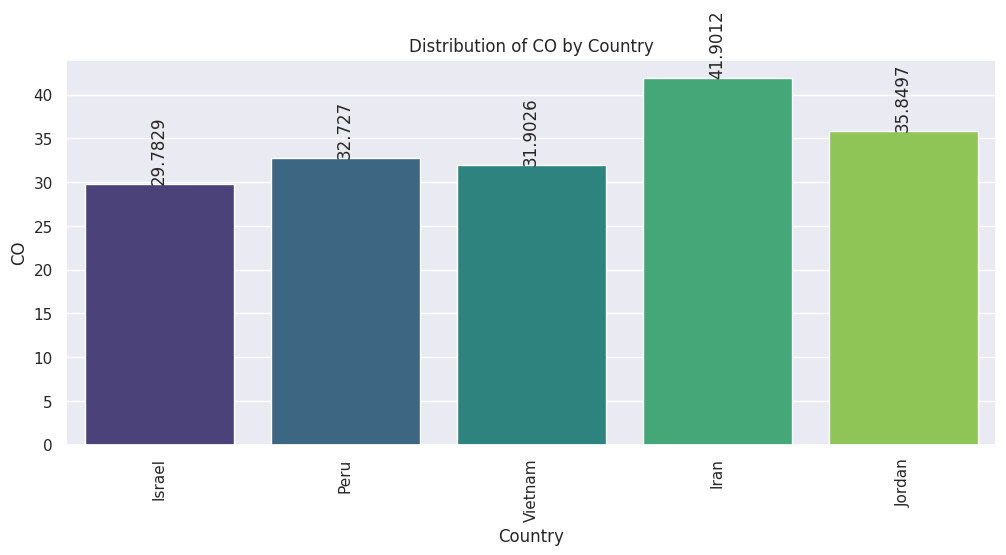

/usr/local/lib/python3.10/dist-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


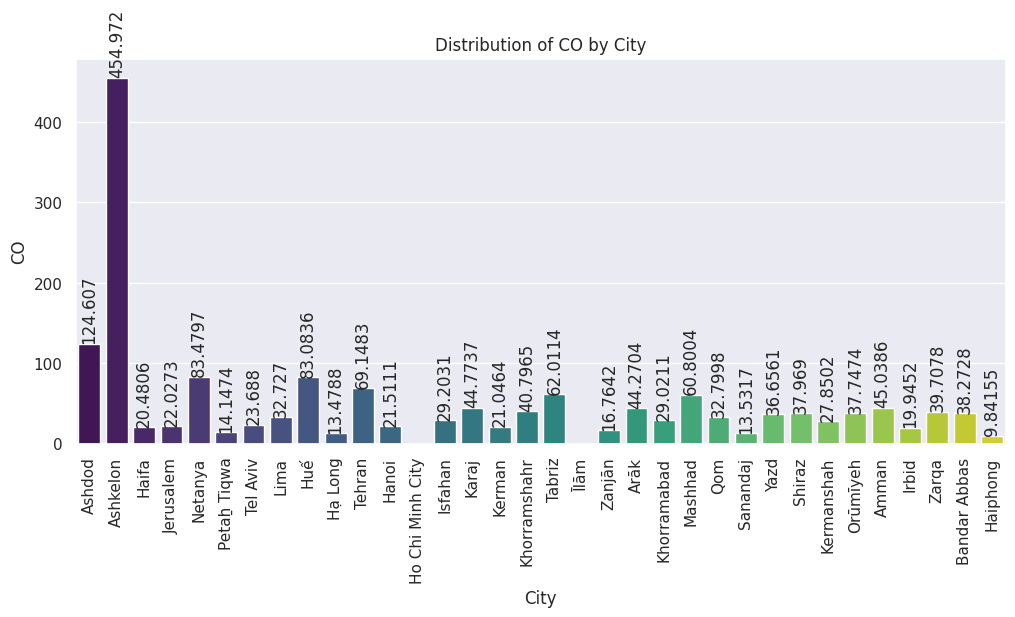

In [29]:
categories = ['Country', 'City']

sns.set(rc={'figure.figsize': (12, 5)})

for c in categories:
    ax = sns.barplot(
        x=c,
        y="co",
        data=filtered_data,
        ci=False,
        palette='viridis'
    )
    # Add bar labels
    for container in ax.containers:
        ax.bar_label(container, rotation=90)
    ax.xaxis.set_tick_params(rotation=90)  # Rotate x-axis labels for better readability
    plt.title(f"Distribution of CO by {c}")
    plt.ylabel("CO")
    plt.xlabel(c)
    plt.show()

In [30]:
new_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1342220 entries, 0 to 1462739
Data columns (total 13 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Date         1342220 non-null  object 
 1   Country      1342220 non-null  object 
 2   City         1342220 non-null  object 
 3   co           883209 non-null   float64
 4   no2          1149083 non-null  float64
 5   o3           1088510 non-null  float64
 6   pm10         1149985 non-null  float64
 7   pm25         1187224 non-null  float64
 8   so2          953807 non-null   float64
 9   humidity     1007010 non-null  float64
 10  pressure     1003268 non-null  float64
 11  temperature  1007708 non-null  float64
 12  wind-speed   949501 non-null   float64
dtypes: float64(10), object(3)
memory usage: 143.4+ MB


<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


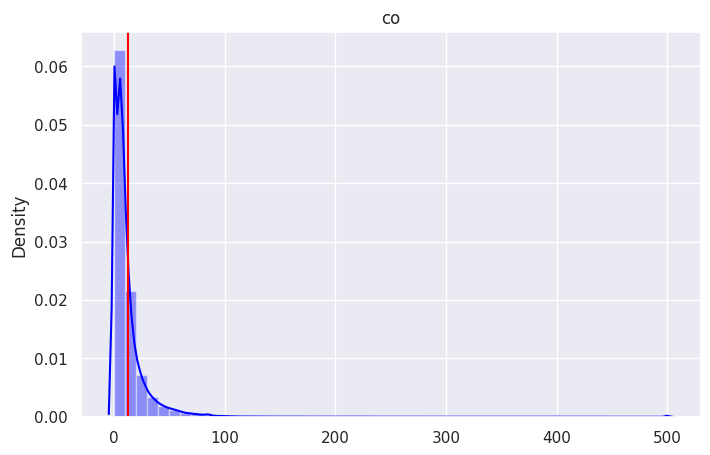

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


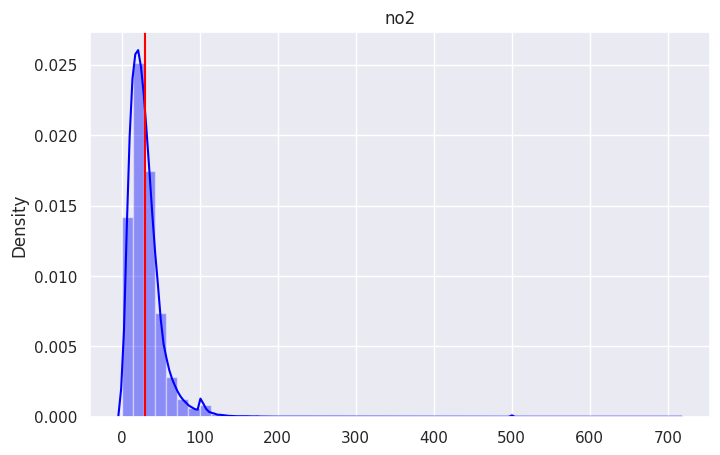

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


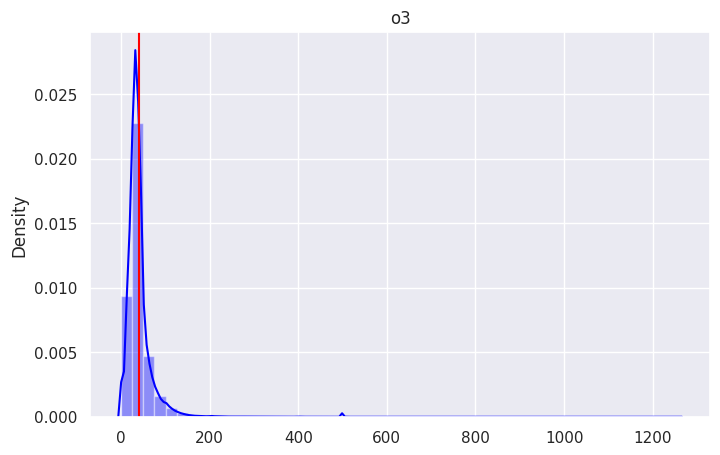

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


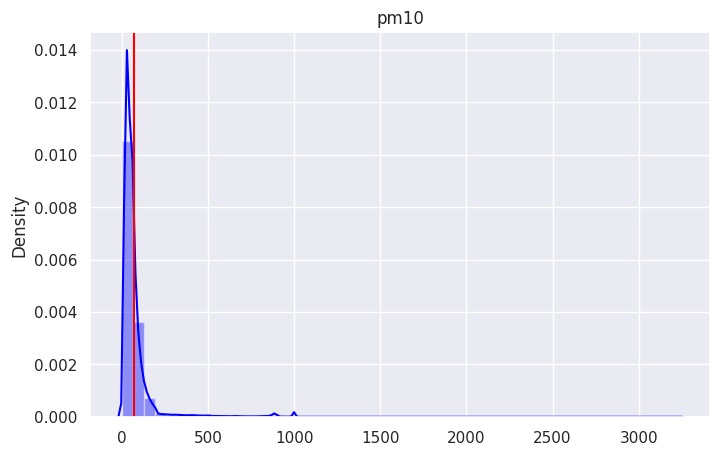

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


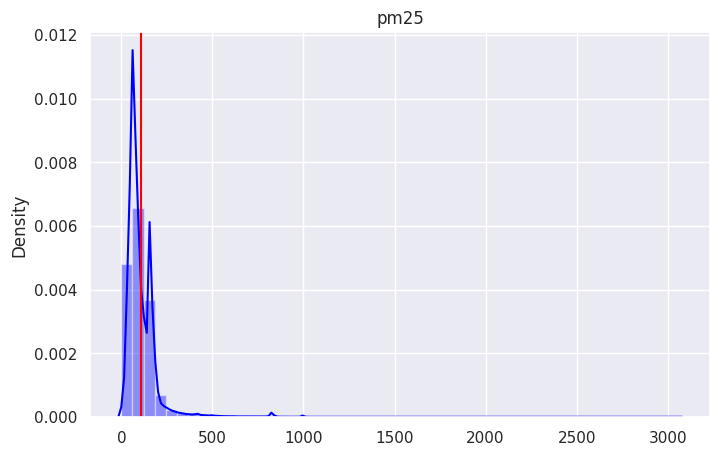

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


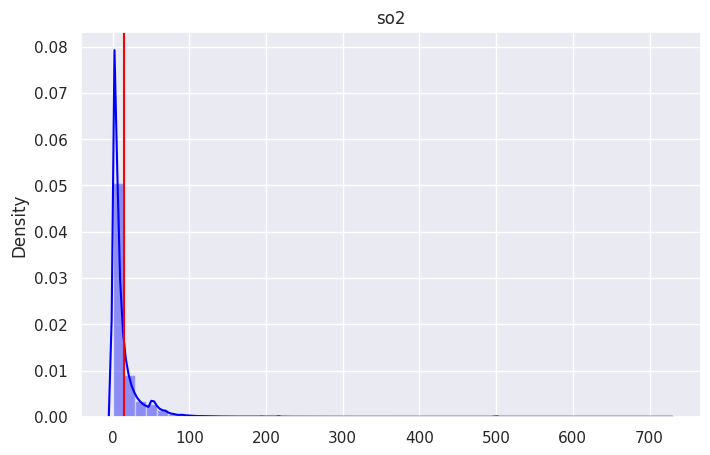

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


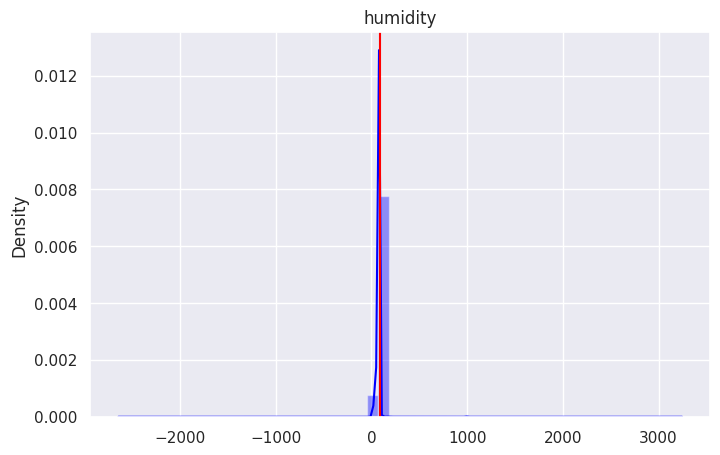

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


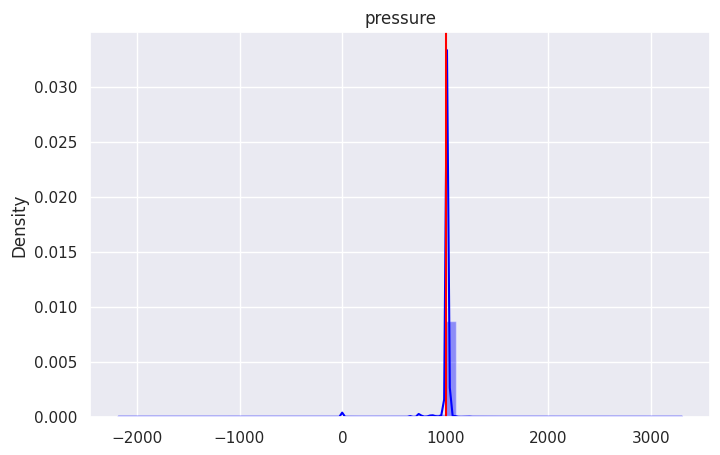

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


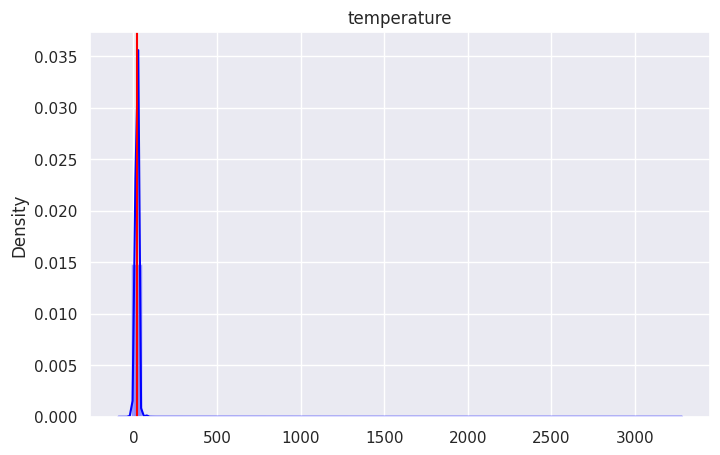

<ipython-input-31-e065b1342f32>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, color = 'blue');


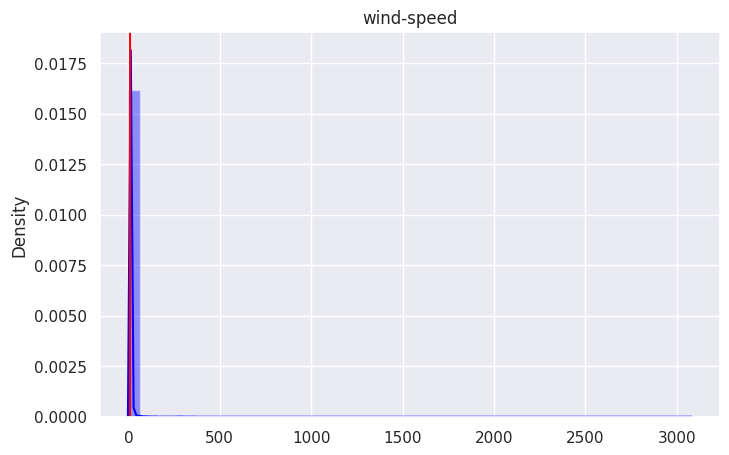

In [31]:
# identifying all numeric columns
numerics = ['int64', 'float64']
n_variables = new_data_cleaned.select_dtypes(include=numerics).columns

# investigate distribution
sns.set(rc={'figure.figsize':(8,5)})

for n in n_variables:
    x = new_data_cleaned[n].values
    sns.distplot(x, color = 'blue');

    # Calculating the mean
    mean = new_data_cleaned[n].mean()

    #ploting the mean
    plt.axvline(mean, 0,1, color = 'red')
    plt.title(n)
    plt.show()

The median for co is: 7.0


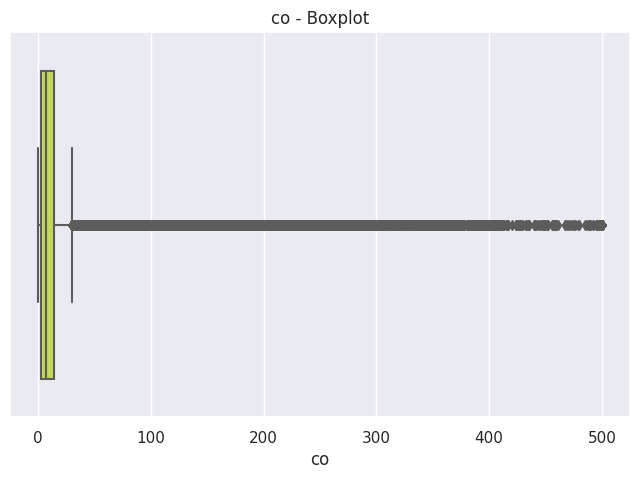

The median for no2 is: 26.0


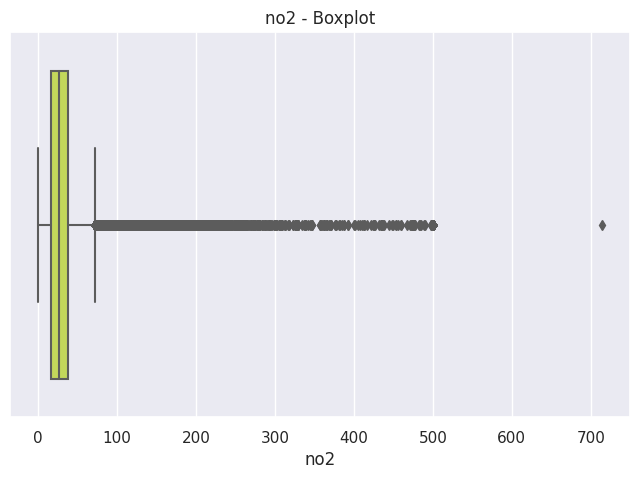

The median for o3 is: 35.2


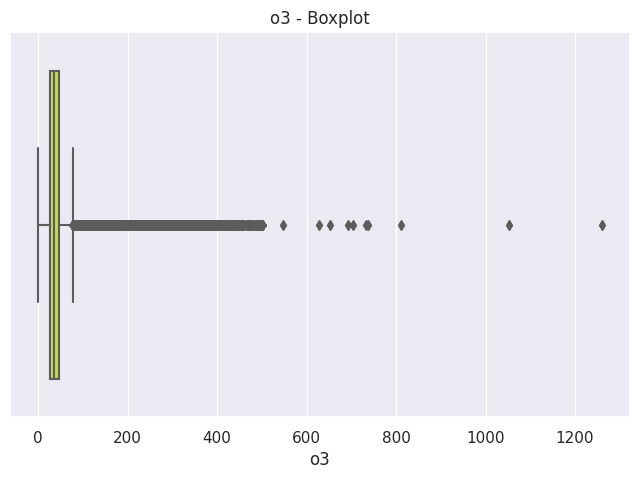

The median for pm10 is: 49.0


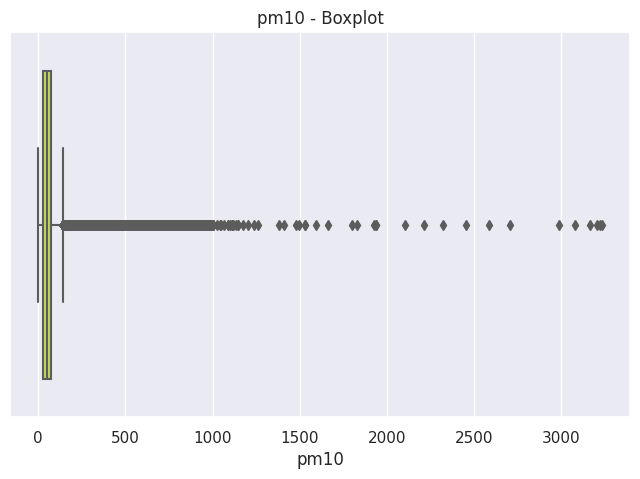

The median for pm25 is: 82.0


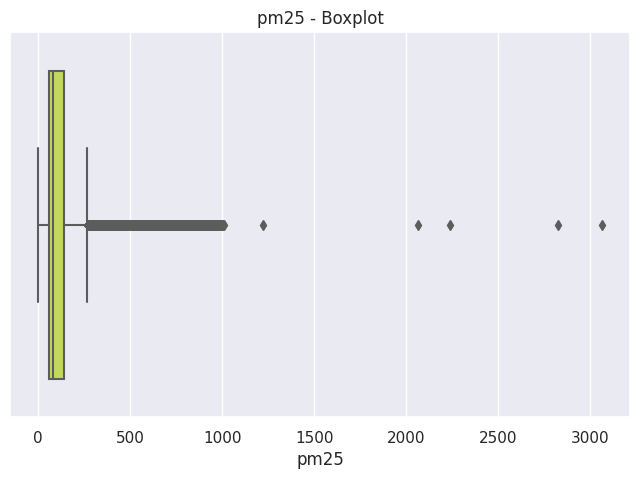

The median for so2 is: 6.2


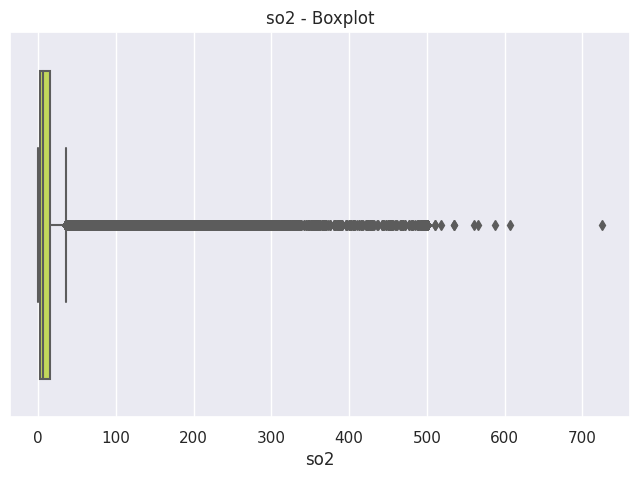

The median for humidity is: 93.0


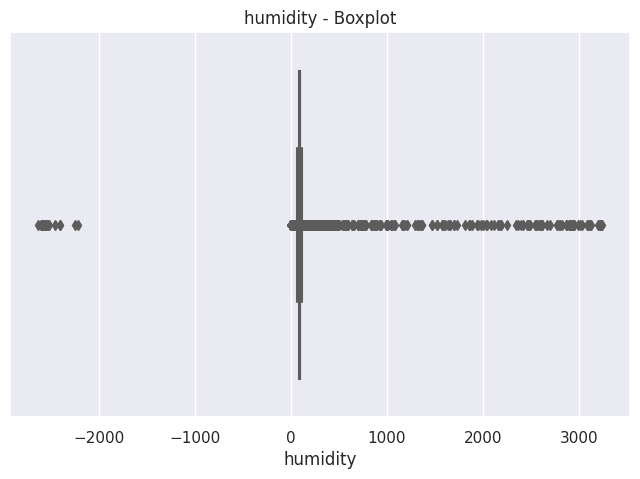

The median for pressure is: 1017.8


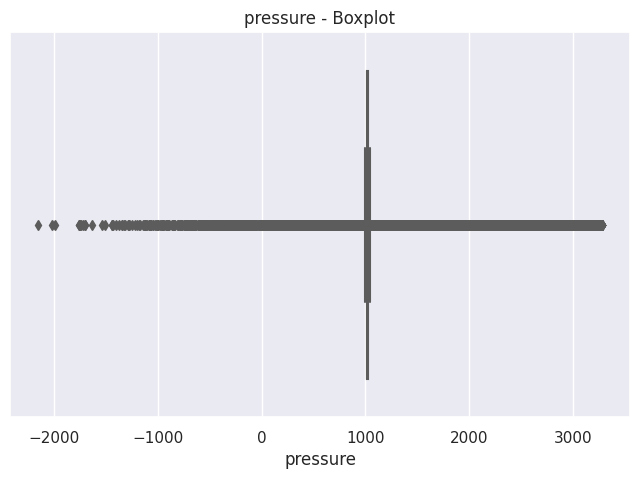

The median for temperature is: 22.5


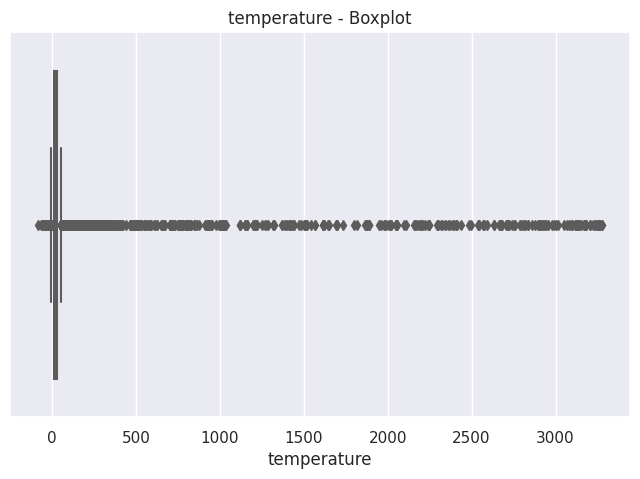

The median for wind-speed is: 5.9


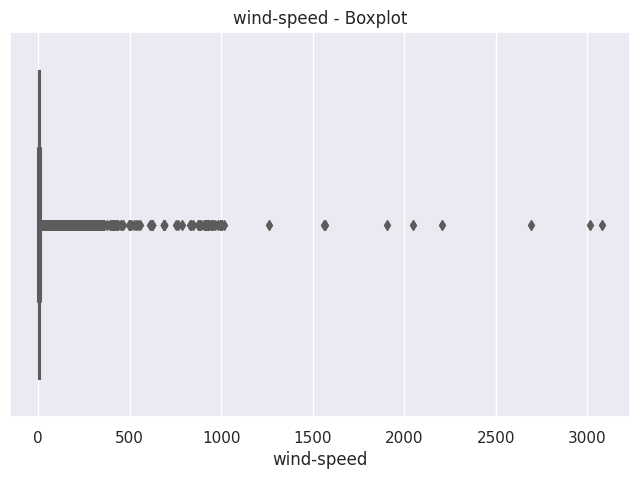

In [32]:
# investigate outliers
sns.set(rc={'figure.figsize': (8, 5)})

for c in n_variables:
    ax = sns.boxplot(x=new_data_cleaned[c], color='#D1EC46')
    plt.title(f"{c} - Boxplot")
    plt.xlabel(c)
    print(f"The median for {c} is: {new_data_cleaned[c].median()}")
    plt.show()

In [33]:
# Find the minimum and maximum dates
min_date = new_data_cleaned['Date'].min()
max_date = new_data_cleaned['Date'].max()

print('Minimum date:', min_date)
print('Maximum date:', max_date)

Minimum date: 2014-12-29
Maximum date: 2024-12-31


In [34]:
os.makedirs("/kaggle/working/", exist_ok=True)
new_data_cleaned.to_csv('/kaggle/working/new_data_2015_2024.csv')